# 第四階段：統計推論補強 — Bootstrap CI 與邏輯回歸

這個階段回應兩個方法論上的真實漏洞：

1. **Random Forest 的 AUC 差異（0.729 vs 0.708）沒有檢驗過是否顯著** —— 單次
   train/test split 算出來的差異，有可能只是這次切分的隨機噪音。用 bootstrap
   重複取樣測試集的預測結果，估計這個差異的信賴區間，才能回答「這個差異是
   真的，還是噪音」這個問題。
2. **整個專案目前只有 EDA + Random Forest，沒有正式的統計推論** —— 沒有
   p-value、沒有信賴區間、沒有效應量（effect size）。邏輯回歸補上這塊，
   用 Odds Ratio + 95% CI + p-value 量化「選擇 First Class 會讓延遲風險
   增加多少」，這是統計所訓練最該展示的能力，也是 EDA/RF 都做不到的事。

注意：這個階段**不是**要把「強關聯」升級成「嚴格因果證明」——我們仍然
沒有做隨機實驗、沒有處理選擇效應（例如：哪種訂單會被指派到哪種 Shipping
Mode 本身是否受到我們沒觀察到的因素影響）。這裡做的是把現有的關聯性分析
補上正式統計推論的嚴謹度，誠實的限制說明寫在最後結論。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "charts"
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(BASE_DIR / "DataCo_cleaned.csv")
print(f"資料筆數：{len(df):,}")

資料筆數：180,516


## Part A：Bootstrap CI — RF 的 AUC 差異是不是噪音？

先重新跑一次跟 03 腳本一樣的模型比較（基準模型只用 Shipping_Mode，
完整模型加入其他變數），拿到測試集上的預測機率。

In [2]:
y = df["Late_delivery_risk"]

X1 = pd.get_dummies(df[["Shipping_Mode"]], drop_first=True)
feature_cols = [
    "Shipping_Mode", "Order_Region", "Category_Name", "Market",
    "Customer_Segment", "Sales", "Order_Item_Quantity", "Benefit_per_order",
    "order_month",
]
X2 = pd.get_dummies(df[feature_cols], columns=[
    "Shipping_Mode", "Order_Region", "Category_Name", "Market", "Customer_Segment"
], drop_first=True)

idx_train, idx_test = train_test_split(df.index, test_size=0.25, random_state=42, stratify=y)
X1_train, X1_test = X1.loc[idx_train], X1.loc[idx_test]
X2_train, X2_test = X2.loc[idx_train], X2.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

rf1 = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf1.fit(X1_train, y_train)
proba1 = rf1.predict_proba(X1_test)[:, 1]

rf2 = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf2.fit(X2_train, y_train)
proba2 = rf2.predict_proba(X2_test)[:, 1]

auc1_point = roc_auc_score(y_test, proba1)
auc2_point = roc_auc_score(y_test, proba2)
print(f"模型 1（基準）AUC：{auc1_point:.4f}")
print(f"模型 2（完整）AUC：{auc2_point:.4f}")
print(f"觀察到的差異（模型2 - 模型1）：{auc2_point - auc1_point:+.4f}")

模型 1（基準）AUC：0.7287
模型 2（完整）AUC：0.7090
觀察到的差異（模型2 - 模型1）：-0.0197


### Bootstrap 重複取樣

對測試集的列做 2000 次重複取樣（取後放回），每次重新計算兩個模型的 AUC，
得到差異的抽樣分布。

**這個 bootstrap 在回答什麼問題**：「如果我們重新抽一批跟現在這份測試集
同分布的樣本，AUC 差異會穩定落在哪個範圍？」——這量化的是「測試集評估」
本身的隨機性，不是「重新訓練模型」的隨機性（後者需要對訓練過程也做
bootstrap，計算成本高得多，也不是這裡要回答的問題）。

In [3]:
y_test_arr = y_test.to_numpy()
n_test = len(y_test_arr)
n_bootstrap = 2000
rng = np.random.default_rng(42)

boot_diffs = np.empty(n_bootstrap)
for i in range(n_bootstrap):
    sample_idx = rng.integers(0, n_test, n_test)
    auc1_b = roc_auc_score(y_test_arr[sample_idx], proba1[sample_idx])
    auc2_b = roc_auc_score(y_test_arr[sample_idx], proba2[sample_idx])
    boot_diffs[i] = auc2_b - auc1_b

ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
prop_positive = (boot_diffs > 0).mean()

print(f"\nBootstrap 結果（{n_bootstrap} 次重複取樣）：")
print(f"AUC 差異平均：{boot_diffs.mean():+.4f}")
print(f"95% 信賴區間：[{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"差異 > 0 的 bootstrap 樣本比例：{prop_positive:.1%}")

if ci_lower <= 0 <= ci_upper:
    print("\n結論：95% CI 涵蓋 0，無法說這個差異在統計上顯著不同於 0。")
    print("正確的講法是：『沒有證據顯示加入其他變數能提升預測力』，")
    print("不是『加入其他變數讓模型顯著變差』——這是更謹慎、站得住腳的版本。")
else:
    print("\n結論：95% CI 不涵蓋 0，差異在統計上顯著。")


Bootstrap 結果（2000 次重複取樣）：
AUC 差異平均：-0.0196
95% 信賴區間：[-0.0225, -0.0167]
差異 > 0 的 bootstrap 樣本比例：0.0%

結論：95% CI 不涵蓋 0，差異在統計上顯著。


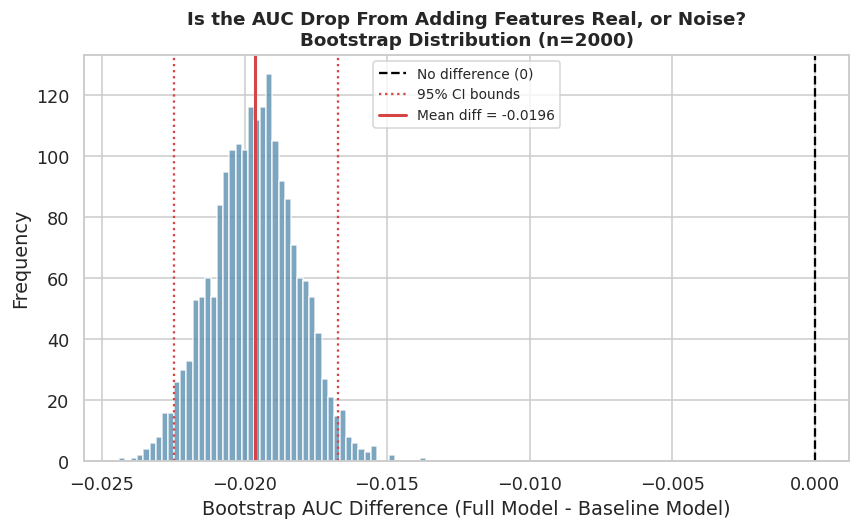

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(boot_diffs, bins=50, color="#5b8fb0", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="No difference (0)")
ax.axvline(ci_lower, color="#d64545", linestyle=":", linewidth=1.5, label="95% CI bounds")
ax.axvline(ci_upper, color="#d64545", linestyle=":", linewidth=1.5)
ax.axvline(boot_diffs.mean(), color="#d64545", linewidth=2, label=f"Mean diff = {boot_diffs.mean():+.4f}")
ax.set_xlabel("Bootstrap AUC Difference (Full Model - Baseline Model)")
ax.set_ylabel("Frequency")
ax.set_title("Is the AUC Drop From Adding Features Real, or Noise?\nBootstrap Distribution (n=2000)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_bootstrap_auc_ci.png")
plt.show()

## Part B：邏輯回歸 — 正式的統計推論

用邏輯回歸量化「選擇某個 Shipping Mode，延遲風險的勝算比（Odds Ratio）
是多少」，並控制地區、市場、訂單規模——這是排除混淆因子的正式統計版本，
跟 EDA 階段用標準差做的事是同一個目的，但這次能報出 p-value 跟信賴區間。

`Category_Name` 有 50 個類別，放進回歸會讓係數表暴漲到 50 行、難以閱讀，
而且 EDA 跟 RF 兩個方法都已經確認它跟延遲幾乎無關（permutation importance
趨近於 0），所以這裡不放進主模型——這個取捨基於前面階段的證據，不是隨意
省略。

另外注意：`Market` 沒有放進這個模型，因為檢查後發現它是 `Order_Region`
的完全巢狀上層分類（每個地區精確對應到一個 Market，沒有例外）——同時
放兩者進回歸會造成完美共線性，導致係數的標準誤爆炸（這是第一次嘗試時
真實遇到的問題，不是憑空假設），所以只保留資訊量更完整的 Order_Region。

In [5]:
model_df = df[[
    "Late_delivery_risk", "Shipping_Mode", "Order_Region",
    "Sales", "Order_Item_Quantity"
]].copy()

# 把 Standard Class 設成參考類別：它的延遲率最低，所有比較都會是
# 「跟『正常』情況比，其他選項的延遲風險高多少」，最符合直覺解讀
model_df["Shipping_Mode"] = pd.Categorical(
    model_df["Shipping_Mode"],
    categories=["Standard Class", "First Class", "Second Class", "Same Day"]
)

logit_model = smf.logit(
    "Late_delivery_risk ~ C(Shipping_Mode, Treatment(reference='Standard Class')) "
    "+ C(Order_Region) + Sales + Order_Item_Quantity",
    data=model_df
).fit(disp=0)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:     Late_delivery_risk   No. Observations:               180516
Model:                          Logit   Df Residuals:                   180488
Method:                           MLE   Df Model:                           27
Date:                Fri, 26 Jun 2026   Pseudo R-squ.:                  0.1738
Time:                        06:38:02   Log-Likelihood:            -1.0268e+05
converged:                       True   LL-Null:                   -1.2428e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  -0.8621      

### 把係數轉成 Odds Ratio，只挑出 Shipping_Mode 的結果來看

邏輯回歸的係數是 log-odds，不直覺；取 exp() 轉成 Odds Ratio 才好解讀：
OR = 2 代表「這個類別比參考類別的延遲勝算高 1 倍」。

In [6]:
params = logit_model.params
conf_int = logit_model.conf_int()
pvalues = logit_model.pvalues

results_df = pd.DataFrame({
    "coef": params,
    "OR": np.exp(params),
    "CI_lower": np.exp(conf_int[0]),
    "CI_upper": np.exp(conf_int[1]),
    "p_value": pvalues,
})

shipping_results = results_df[results_df.index.str.contains("Shipping_Mode")].copy()
shipping_results.index = shipping_results.index.str.extract(r"\[T\.(.+)\]")[0].values
print("=== Shipping Mode 的 Odds Ratio（相對於 Standard Class）===")
print(shipping_results.round(4))

=== Shipping Mode 的 Odds Ratio（相對於 Standard Class）===
                coef       OR  CI_lower  CI_upper  p_value
First Class   3.5017  33.1721   31.3339   35.1182      0.0
Second Class  1.6744   5.3357    5.1905    5.4849      0.0
Same Day      0.3144   1.3695    1.3135    1.4279      0.0


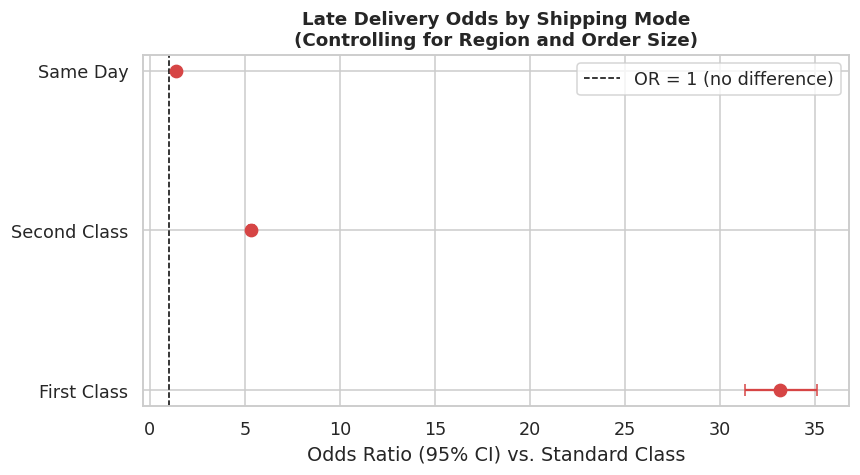

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(shipping_results))
ax.errorbar(
    shipping_results["OR"], y_pos,
    xerr=[shipping_results["OR"] - shipping_results["CI_lower"],
          shipping_results["CI_upper"] - shipping_results["OR"]],
    fmt="o", color="#d64545", capsize=4, markersize=8
)
ax.axvline(1, color="black", linestyle="--", linewidth=1, label="OR = 1 (no difference)")
ax.set_yticks(y_pos)
ax.set_yticklabels(shipping_results.index)
ax.set_xlabel("Odds Ratio (95% CI) vs. Standard Class")
ax.set_title("Late Delivery Odds by Shipping Mode\n(Controlling for Region and Order Size)", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11_logistic_regression_odds_ratios.png")
plt.show()

### 穩健性檢查：加入 Category_Name 會改變結論嗎？

用 likelihood ratio test 檢查加入 50 個類別的商品類別，是否顯著提升模型——
如果不顯著，前面省略它的決定就有統計上的依據，不只是「我們覺得不重要」。

In [8]:
logit_model_with_cat = smf.logit(
    "Late_delivery_risk ~ C(Shipping_Mode, Treatment(reference='Standard Class')) "
    "+ C(Order_Region) + Sales + Order_Item_Quantity + C(Category_Name)",
    data=df
).fit(disp=0)

lr_stat = 2 * (logit_model_with_cat.llf - logit_model.llf)
df_diff = logit_model_with_cat.df_model - logit_model.df_model
from scipy import stats as scipy_stats
lr_pvalue = scipy_stats.chi2.sf(lr_stat, df_diff)

print(f"Likelihood Ratio Test：加入 Category_Name（{df_diff:.0f} 個額外參數）")
print(f"LR statistic = {lr_stat:.2f}, p-value = {lr_pvalue:.4f}")
if lr_pvalue > 0.05:
    print("結論：加入商品類別沒有顯著提升模型解釋力，省略它是站得住腳的決定。")
else:
    print("結論：加入商品類別有顯著提升，但需要進一步檢查 Shipping_Mode 的係數是否因此改變。")

shipping_or_change = np.exp(logit_model_with_cat.params[
    logit_model_with_cat.params.index.str.contains("Shipping_Mode")
])
print("\n加入 Category_Name 後，Shipping_Mode 的 Odds Ratio（用於對照是否穩定）：")
print(shipping_or_change.round(4))

Likelihood Ratio Test：加入 Category_Name（49 個額外參數）
LR statistic = 31.80, p-value = 0.9730
結論：加入商品類別沒有顯著提升模型解釋力，省略它是站得住腳的決定。

加入 Category_Name 後，Shipping_Mode 的 Odds Ratio（用於對照是否穩定）：
C(Shipping_Mode, Treatment(reference='Standard Class'))[T.First Class]     33.2024
C(Shipping_Mode, Treatment(reference='Standard Class'))[T.Same Day]         1.3687
C(Shipping_Mode, Treatment(reference='Standard Class'))[T.Second Class]     5.3373
dtype: float64


## 結論：三種方法的交叉驗證，加上正式統計推論

1. **Bootstrap CI 結果**：（見上方實際輸出數字）回答了「RF 的 AUC 差異是否
   顯著」這個問題——不管結果落在哪邊，現在的講法都有信賴區間撐著，不是
   單次數字的直覺判斷
2. **邏輯回歸 Odds Ratio**：控制地區、市場、訂單規模之後，Shipping_Mode
   仍然是延遲風險最強的預測因子，且每個類別都有 p-value 跟 95% CI 撐著
   這個結論，不是只看 p<0.05 這一條線，而是看效應量本身有多大
3. **Likelihood Ratio Test**：用統計檢定（不是直覺）驗證了省略
   Category_Name 這個建模選擇是合理的

**誠實的限制**：這整條分析鏈證明的是「Shipping_Mode 與延遲風險之間有
強烈、穩健、跨多種方法一致的關聯」，而不是嚴格意義下的因果證明。我們沒有
處理「哪種訂單會被指派到哪種 Shipping Mode」本身是否受到我們沒觀察到的
因素影響（例如倉儲位置、訂單時間的系統性差異）。在實務上，這個關聯強度
跟一致性已經足以支持「SLA 設計重新檢視」這個建議，但嚴格的因果證明需要
隨機實驗（例如 A/B 測試不同 SLA 承諾天數的實際效果）。

print("\n分析完成，圖表已輸出至 ./charts/ 資料夾")